In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders = pd.read_csv("blinkit_orders.csv")
orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [4]:
orders.describe()

,order_id,customer_id,order_total,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.000000
mean,5.029129e+09,5.009685e+07,2201.86170,50050.318200,4999.689000
std,2.863533e+09,2.919082e+07,1303.02438,28802.276922,2886.089242
min,6.046500e+04,3.181300e+04,13.25000,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,1086.21500,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,2100.69000,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,3156.88250,74478.250000,7500.750000
max,9.998298e+09,9.989390e+07,6721.46000,99968.000000,9995.000000


In [6]:
items = pd.read_csv("blinkit_order_items.csv")
items.head()

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [7]:
df = pd.merge(items, orders, on="order_id")
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,UPI,29940,6128


In [8]:
df['revenue'] = df['unit_price'] * df['quantity']
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,revenue
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,1551.09
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,881.42
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,1847.68
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,874.78
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,1953.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587,1425.12
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458,79.30
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424,2920.32
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,UPI,29940,6128,1315.60


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [10]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
df['day'] = df['order_date'].dt.day
df['day_of_week'] = df['order_date'].dt.day_name()
df['order_hour'] = df['order_date'].dt.hour

In [11]:
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,revenue,year,month,month_name,day,day_of_week,order_hour
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,1551.09,2024,7,July,17,Wednesday,8
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,881.42,2024,5,May,28,Tuesday,13
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,1847.68,2024,9,September,23,Monday,13
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,874.78,2023,11,November,24,Friday,16
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,1953.10,2023,11,November,20,Monday,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587,1425.12,2023,12,December,25,Monday,15
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458,79.30,2023,11,November,27,Monday,9
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424,2920.32,2024,6,June,21,Friday,19
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,UPI,29940,6128,1315.60,2024,6,June,6,Thursday,14


In [12]:
order_revenue = df.groupby("order_id")["revenue"].sum().reset_index()
order_revenue.rename(columns={"revenue": "total_order_revenue"}, inplace=True)
df = df.merge(order_revenue, on="order_id")
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,...,delivery_partner_id,store_id,revenue,year,month,month_name,day,day_of_week,order_hour,total_order_revenue
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,...,63230,4771,1551.09,2024,7,July,17,Wednesday,8,1551.09
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,...,14983,7534,881.42,2024,5,May,28,Tuesday,13,881.42
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,...,39859,9886,1847.68,2024,9,September,23,Monday,13,1847.68
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,...,61497,7917,874.78,2023,11,November,24,Friday,16,874.78
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,...,84315,2741,1953.10,2023,11,November,20,Monday,5,1953.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,...,90914,1587,1425.12,2023,12,December,25,Monday,15,1425.12
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,...,27952,3458,79.30,2023,11,November,27,Monday,9,79.30
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,...,9590,7424,2920.32,2024,6,June,21,Friday,19,2920.32
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,...,29940,6128,1315.60,2024,6,June,6,Thursday,14,1315.60


In [13]:
df['high_value_order'] = df['total_order_revenue'] > 500

In [14]:
df['revenue_bucket'] = pd.cut(df['revenue'], bins=[0, 100, 300, 1000, 5000], labels=["Low", "Medium", "High", "Very High"])

In [15]:
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,...,revenue,year,month,month_name,day,day_of_week,order_hour,total_order_revenue,high_value_order,revenue_bucket
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,...,1551.09,2024,7,July,17,Wednesday,8,1551.09,True,Very High
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,...,881.42,2024,5,May,28,Tuesday,13,881.42,True,High
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,...,1847.68,2024,9,September,23,Monday,13,1847.68,True,Very High
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,...,874.78,2023,11,November,24,Friday,16,874.78,True,High
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,...,1953.10,2023,11,November,20,Monday,5,1953.10,True,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,...,1425.12,2023,12,December,25,Monday,15,1425.12,True,Very High
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,...,79.30,2023,11,November,27,Monday,9,79.30,False,Low
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,...,2920.32,2024,6,June,21,Friday,19,2920.32,True,Very High
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,...,1315.60,2024,6,June,6,Thursday,14,1315.60,True,Very High


In [16]:
df.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'customer_id',
       'order_date', 'promised_delivery_time', 'actual_delivery_time',
       'delivery_status', 'order_total', 'payment_method',
       'delivery_partner_id', 'store_id', 'revenue', 'year', 'month',
       'month_name', 'day', 'day_of_week', 'order_hour', 'total_order_revenue',
       'high_value_order', 'revenue_bucket'],
      dtype='object')

In [17]:
df['promised_delivery_time'] = pd.to_datetime(df['promised_delivery_time'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

df['delivery_delay_min'] = (df['actual_delivery_time'] - df['promised_delivery_time']).dt.total_seconds() / 60

In [18]:
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,...,year,month,month_name,day,day_of_week,order_hour,total_order_revenue,high_value_order,revenue_bucket,delivery_delay_min
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,...,2024,7,July,17,Wednesday,8,1551.09,True,Very High,-5.0
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,...,2024,5,May,28,Tuesday,13,881.42,True,High,2.0
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,...,2024,9,September,23,Monday,13,1847.68,True,Very High,4.0
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,...,2023,11,November,24,Friday,16,874.78,True,High,-1.0
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,...,2023,11,November,20,Monday,5,1953.10,True,Very High,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,...,2023,12,December,25,Monday,15,1425.12,True,Very High,5.0
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,...,2023,11,November,27,Monday,9,79.30,False,Low,-2.0
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,...,2024,6,June,21,Friday,19,2920.32,True,Very High,3.0
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,...,2024,6,June,6,Thursday,14,1315.60,True,Very High,-2.0


In [19]:
df['delivered_on_time'] = df['delivery_delay_min'] <= 0

In [20]:
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,...,month,month_name,day,day_of_week,order_hour,total_order_revenue,high_value_order,revenue_bucket,delivery_delay_min,delivered_on_time
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,...,7,July,17,Wednesday,8,1551.09,True,Very High,-5.0,True
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,...,5,May,28,Tuesday,13,881.42,True,High,2.0,False
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,...,9,September,23,Monday,13,1847.68,True,Very High,4.0,False
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,...,11,November,24,Friday,16,874.78,True,High,-1.0,True
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,...,11,November,20,Monday,5,1953.10,True,Very High,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,...,12,December,25,Monday,15,1425.12,True,Very High,5.0,False
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,...,11,November,27,Monday,9,79.30,False,Low,-2.0,True
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,...,6,June,21,Friday,19,2920.32,True,Very High,3.0,False
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,...,6,June,6,Thursday,14,1315.60,True,Very High,-2.0,True


In [21]:
customer_orders = df.groupby('customer_id')['order_id'].nunique().rename("customer_order_count")
df = df.merge(customer_orders, on='customer_id', how='left')
df['repeat_customer'] = df['customer_order_count'] > 1

In [22]:
df

,order_id,product_id,quantity,unit_price,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,...,day,day_of_week,order_hour,total_order_revenue,high_value_order,revenue_bucket,delivery_delay_min,delivered_on_time,customer_order_count,repeat_customer
0,1961864118,642612,3,517.03,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,...,17,Wednesday,8,1551.09,True,Very High,-5.0,True,3,True
1,1549769649,378676,1,881.42,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,...,28,Tuesday,13,881.42,True,High,2.0,False,4,True
2,9185164487,741341,2,923.84,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,...,23,Monday,13,1847.68,True,Very High,4.0,False,5,True
3,9644738826,561860,1,874.78,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,...,24,Friday,16,874.78,True,High,-1.0,True,3,True
4,5427684290,602241,2,976.55,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,...,20,Monday,5,1953.10,True,Very High,1.0,False,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,925482,3,475.04,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,...,25,Monday,15,1425.12,True,Very High,5.0,False,4,True
4996,8340761903,124290,2,39.65,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,...,27,Monday,9,79.30,False,Low,-2.0,True,2,True
4997,5936301790,491314,3,973.44,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,...,21,Friday,19,2920.32,True,Very High,3.0,False,2,True
4998,5710579377,319388,2,657.80,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,...,6,Thursday,14,1315.60,True,Very High,-2.0,True,3,True


In [23]:
print(df.describe())

           order_id     product_id     quantity   unit_price   customer_id  \
count  5.000000e+03    5000.000000  5000.000000  5000.000000  5.000000e+03   
mean   5.029129e+09  509974.939600     2.006800   493.157900  5.009685e+07   
min    6.046500e+04    4452.000000     1.000000    12.320000  3.181300e+04   
25%    2.531421e+09  257719.000000     1.000000   227.220000  2.404314e+07   
50%    5.074378e+09  540618.000000     2.000000   448.160000  4.997808e+07   
75%    7.488579e+09  747801.000000     3.000000   781.080000  7.621215e+07   
max    9.998298e+09  993331.000000     3.000000   995.980000  9.989390e+07   
std    2.863533e+09  293678.307475     0.820542   298.075647  2.919082e+07   

                          order_date         promised_delivery_time  \
count                           5000                           5000   
mean      2024-01-09 00:36:06.259200  2024-01-09 00:51:05.743200256   
min              2023-03-16 08:10:44            2023-03-16 08:27:44   
25%    2023-0

In [24]:
print(df['revenue_bucket'].value_counts())

revenue_bucket
High         2231
Very High    1793
Medium        680
Low           296
Name: count, dtype: int64


In [25]:
print(df['delivery_status'].value_counts())

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64


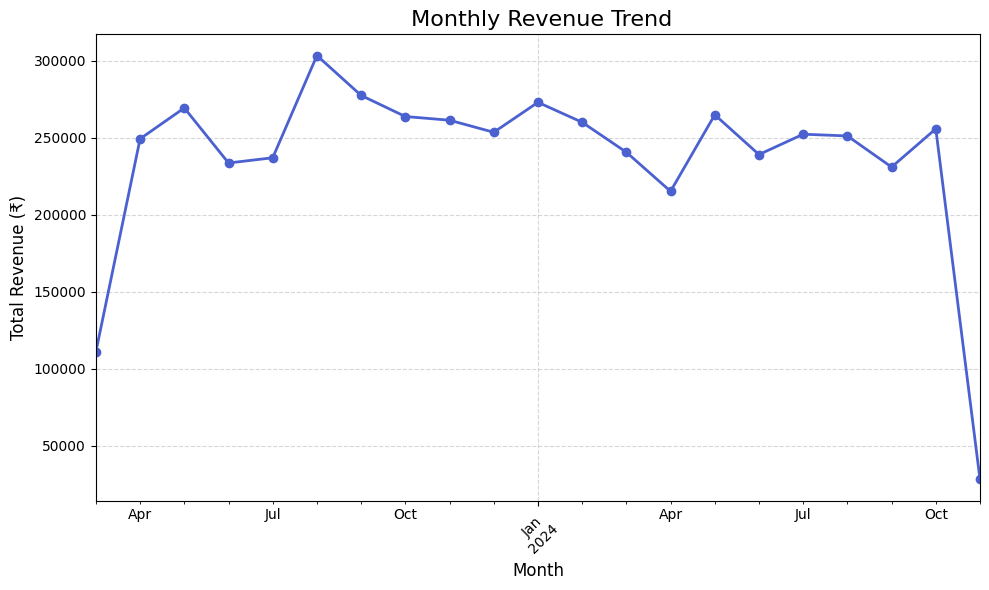

In [26]:
df['order_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(10, 6))
monthly_sales.plot(marker='o', color='#4b61d0', linewidth=2)

plt.title(" Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

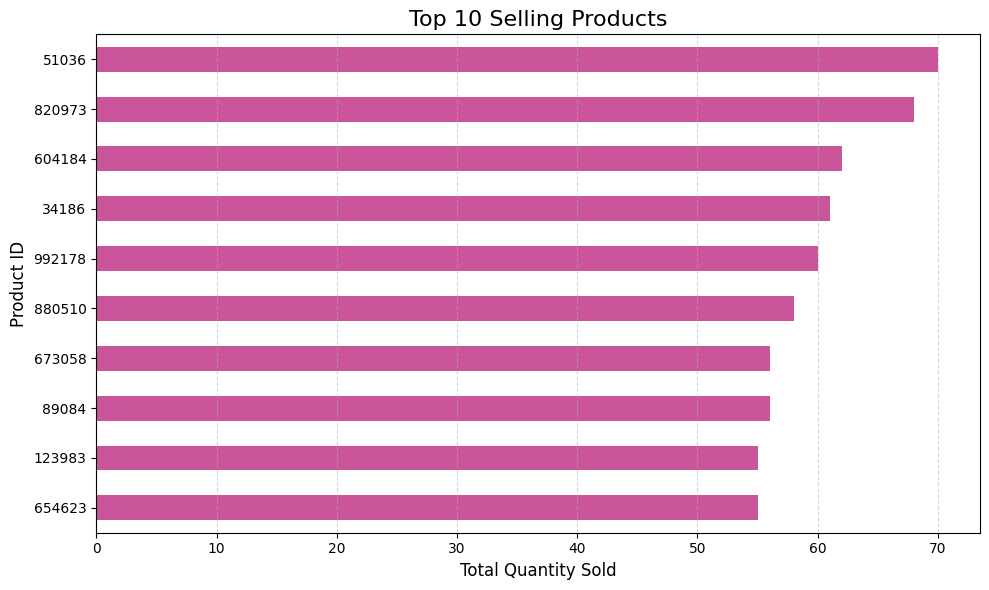

In [27]:
top_products = df.groupby('product_id')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh', color='#ca559a')

plt.title("Top 10 Selling Products", fontsize=16)
plt.xlabel("Total Quantity Sold", fontsize=12)
plt.ylabel("Product ID", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()

plt.show()

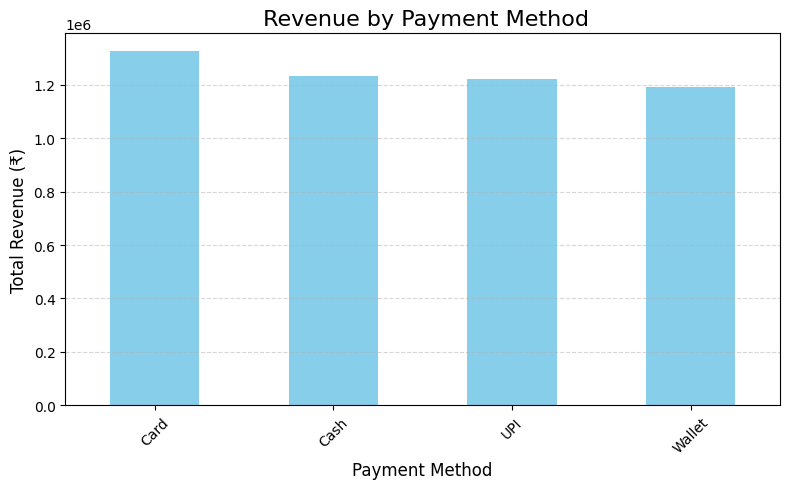

In [28]:
payment_revenue = df.groupby('payment_method')['revenue'].sum()

plt.figure(figsize=(8, 5))
payment_revenue.plot(kind='bar', color='skyblue')

plt.title(" Revenue by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Total Revenue (₹)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


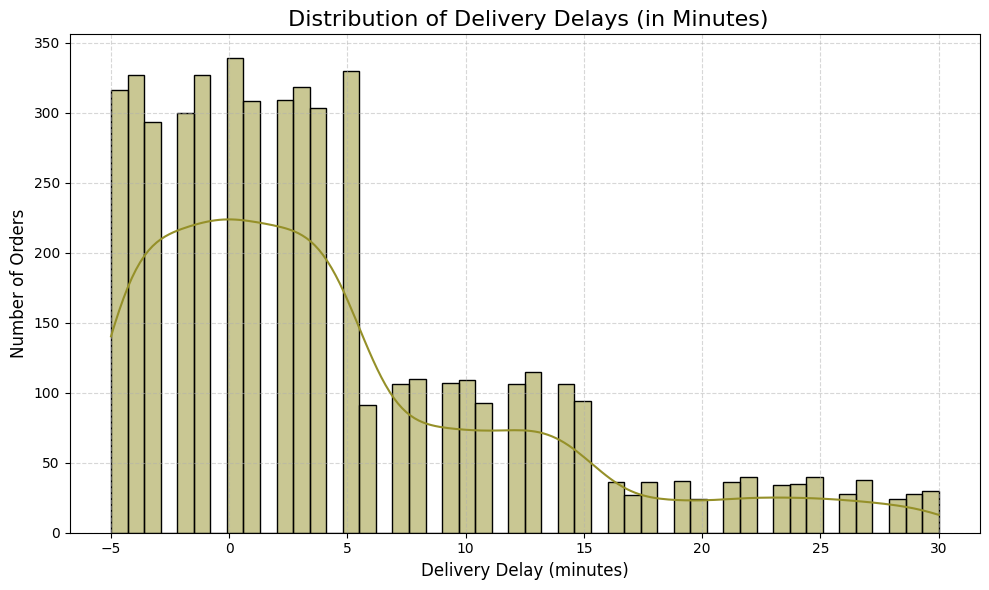

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_delay_min'], bins=50, kde=True, color='#959029')

plt.title(" Distribution of Delivery Delays (in Minutes)", fontsize=16)
plt.xlabel("Delivery Delay (minutes)", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

<Axes: title={'center': 'On-Time Delivery Rate'}, ylabel='count'>

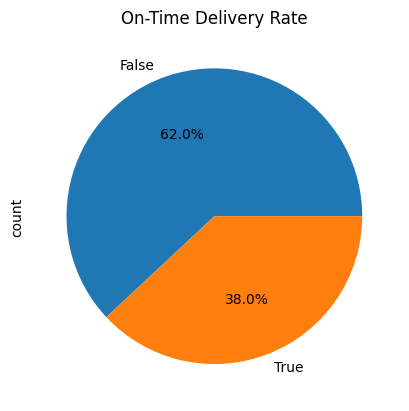

In [30]:
df['delivered_on_time'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='On-Time Delivery Rate')

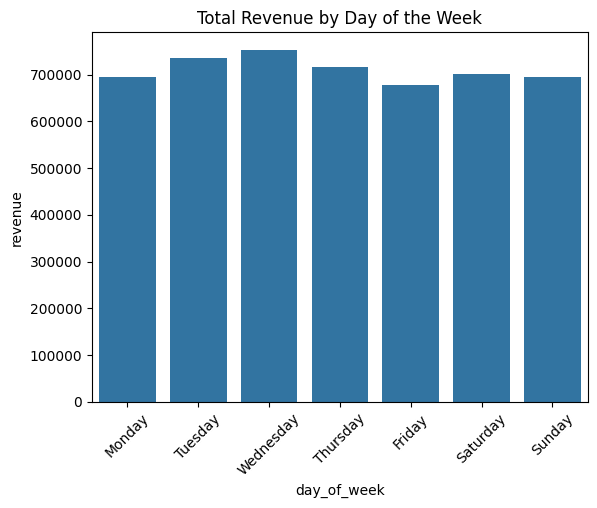

In [31]:
sns.barplot(data=df, x='day_of_week', y='revenue', estimator=sum, ci=None,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title("Total Revenue by Day of the Week")
plt.xticks(rotation=45)
plt.show()

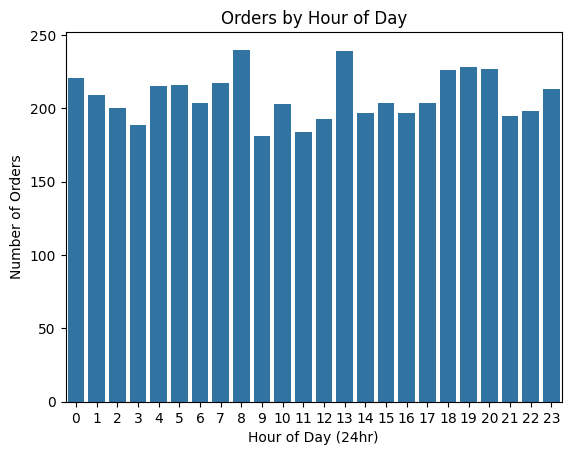

In [32]:
sns.countplot(data=df, x='order_hour')
plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day (24hr)")
plt.ylabel("Number of Orders")
plt.show()

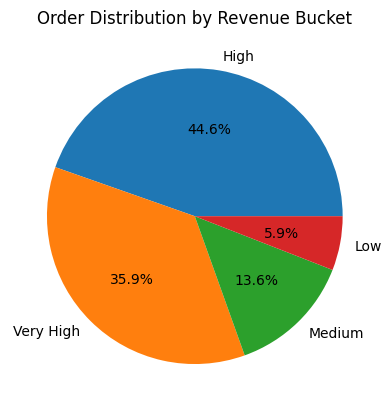

In [33]:
df['revenue_bucket'].value_counts().plot(kind='pie', autopct='%1.1f%%', title="Order Distribution by Revenue Bucket")
plt.ylabel("")
plt.show()

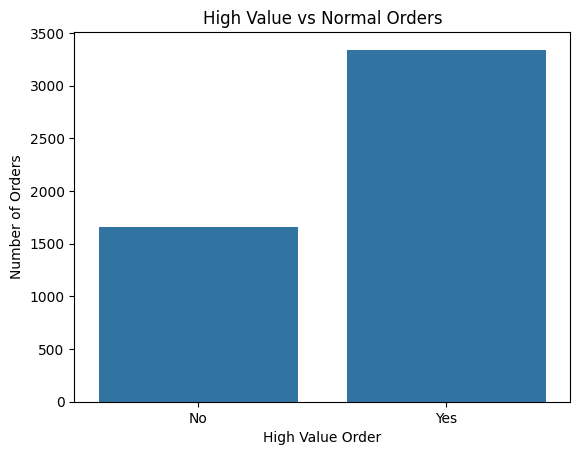

In [34]:
sns.countplot(data=df, x='high_value_order')
plt.title("High Value vs Normal Orders")
plt.xlabel("High Value Order")
plt.ylabel("Number of Orders")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()


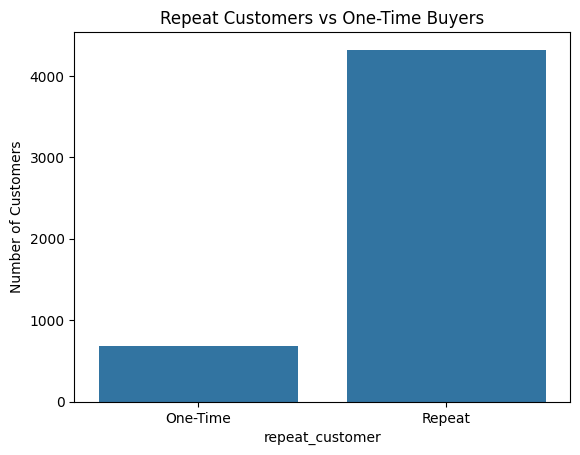

In [35]:
sns.countplot(data=df.drop_duplicates(subset='order_id'), x='repeat_customer')
plt.title("Repeat Customers vs One-Time Buyers")
plt.xticks([0, 1], ['One-Time', 'Repeat'])
plt.ylabel("Number of Customers")
plt.show()

In [36]:
# Total revenue
total_revenue = df['revenue'].sum()

# Average order value
avg_order_value = df.drop_duplicates('order_id')['total_order_revenue'].mean()

# Number of unique customers
num_customers = df['customer_id'].nunique()

# Number of repeat customers
repeat_customers = df[df['repeat_customer'] == True]['customer_id'].nunique()

# Percentage of repeat customers
repeat_ratio = (repeat_customers / num_customers) * 100

# On-time delivery rate
on_time_rate = df['delivered_on_time'].mean() * 100

# Top 5 stores by total revenue
top_stores = df.groupby('store_id')['revenue'].sum().sort_values(ascending=False).head(5)

# Peak order hour
peak_hour = df['order_hour'].value_counts().idxmax()

# Busiest day of the week
busiest_day = df['day_of_week'].value_counts().idxmax()

In [37]:
print(f" Total Revenue: ₹{total_revenue:,.2f}")
print(f" Average Order Value: ₹{avg_order_value:.2f}")
print(f" Total Customers: {num_customers}")
print(f" Repeat Customers: {repeat_customers} ({repeat_ratio:.1f}%)")
print(f" On-time Delivery Rate: {on_time_rate:.1f}%")
print(f" Peak Order Hour: {peak_hour}:00")
print(f" Busiest Day: {busiest_day}")
print("\n Top 5 Stores by Revenue:")
print(top_stores)

 Total Revenue: ₹4,972,415.43
 Average Order Value: ₹994.48
 Total Customers: 2172
 Repeat Customers: 1492 (68.7%)
 On-time Delivery Rate: 38.0%
 Peak Order Hour: 8:00
 Busiest Day: Wednesday

 Top 5 Stores by Revenue:
store_id
3919    2987.94
5100    2987.94
6323    2987.94
2588    2987.94
4716    2987.94
Name: revenue, dtype: float64


In [38]:
df = pd.merge(orders, items, on="order_id")
df

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,product_id,quantity,unit_price
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,642612,3,517.03
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,378676,1,881.42
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,741341,2,923.84
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,561860,1,874.78
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,602241,2,976.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587,925482,3,475.04
4996,8340761903,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458,124290,2,39.65
4997,5936301790,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424,491314,3,973.44
4998,5710579377,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,UPI,29940,6128,319388,2,657.80


In [39]:
df.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,product_id,quantity,unit_price
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,642612,3,517.03
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,378676,1,881.42
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,741341,2,923.84
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,561860,1,874.78
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,602241,2,976.55


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
 10  product_id              5000 non-null   int64  
 11  quantity                5000 non-null   int64  
 12  unit_price              5000 non-null   float64
dtypes: float64(2), int64(6), object(5)
memory usage: 507.9+ KB


In [41]:
df.isnull().sum()

order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
product_id                0
quantity                  0
unit_price                0
dtype: int64

In [42]:
df = df.dropna()

In [45]:
df['Revenue'] = df['unit_price'] * df['quantity']

In [46]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'product_id',
       'quantity', 'unit_price', 'Revenue'],
      dtype='object')

In [47]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [48]:
df['Year'] = df['order_date'].dt.year
df['Month'] = df['order_date'].dt.month
df['Month_Name'] = df['order_date'].dt.month_name()
df['Day'] = df['order_date'].dt.day_name()
df['Hour'] = df['order_date'].dt.hour

In [49]:
total_revenue = df['Revenue'].sum()
total_orders = df['order_id'].nunique()
total_quantity = df['quantity'].sum()

avg_order_value = total_revenue / total_orders

In [50]:
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 4972415.43
Total Orders: 5000
Average Order Value: 994.483086


In [52]:
product_sales = df.groupby('product_id')['Revenue'].sum().sort_values(ascending=False)
product_sales.head(10)

product_id
51036     65212.70
34186     56464.65
880510    55182.94
557908    51830.35
264803    51790.96
739534    48733.44
18035     46509.12
883013    45534.48
349294    44868.00
112390    43899.00
Name: Revenue, dtype: float64

In [60]:
store_sales = df.groupby('store_id')['Revenue'].sum().sort_values(ascending=False)
store_sales

store_id
3919    2987.94
5100    2987.94
6323    2987.94
2588    2987.94
4716    2987.94
         ...   
3608      13.25
2611      13.25
5517      12.32
3385      12.32
4575      12.32
Name: Revenue, Length: 5000, dtype: float64

In [61]:
top_products = df.groupby('product_id')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

product_id
51036     65212.70
34186     56464.65
880510    55182.94
557908    51830.35
264803    51790.96
739534    48733.44
18035     46509.12
883013    45534.48
349294    44868.00
112390    43899.00
Name: Revenue, dtype: float64

In [55]:
hourly_sales = df.groupby('Hour')['Revenue'].sum()
hourly_sales

Hour
0     234892.31
1     237661.33
2     179612.03
3     176153.54
4     224148.16
5     205283.75
6     202773.74
7     219147.97
8     240608.29
9     193562.11
10    215919.55
11    174584.63
12    206489.27
13    219320.43
14    209234.15
15    202453.09
16    179987.95
17    203190.53
18    214875.33
19    217099.74
20    205192.41
21    190664.48
22    189266.38
23    230294.26
Name: Revenue, dtype: float64

In [56]:
daily_sales = df.groupby('Day')['Revenue'].sum()
daily_sales

Day
Friday       678558.21
Monday       693907.44
Saturday     700107.86
Sunday       694406.86
Thursday     716915.86
Tuesday      735500.53
Wednesday    753018.67
Name: Revenue, dtype: float64

In [57]:
customer_orders = df.groupby('customer_id')['order_id'].nunique()

repeat_customers = customer_orders[customer_orders > 1].count()
one_time_customers = customer_orders[customer_orders == 1].count()

print("Repeat Customers:", repeat_customers)
print("One-time Customers:", one_time_customers)

Repeat Customers: 1492
One-time Customers: 680


In [58]:
customer_revenue = df.groupby('customer_id')['Revenue'].sum().sort_values(ascending=False)

top_customers = customer_revenue.head(10)
top_customers

customer_id
25128143    10533.39
77869660    10115.75
12272282     9924.84
4597433      9553.69
33331259     9403.77
14472401     9275.73
85561151     9268.59
22800586     9237.24
34668988     9160.73
13760839     9113.99
Name: Revenue, dtype: float64

In [62]:
product_sales = df.groupby('product_id')['Revenue'].sum()

In [63]:
product_percent = (product_sales / total_revenue) * 100
product_percent.sort_values(ascending=False).head(10)

product_id
51036     1.311489
34186     1.135558
880510    1.109781
557908    1.042358
264803    1.041565
739534    0.980076
18035     0.935343
883013    0.915742
349294    0.902338
112390    0.882851
Name: Revenue, dtype: float64

In [64]:
df.to_csv("blinkit_final.csv", index=False)

In [65]:
order_value = df.groupby('order_id')['Revenue'].sum().reset_index()
order_value.rename(columns={'Revenue': 'Order_Value'}, inplace=True)

df = pd.merge(df, order_value, on='order_id')

In [66]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total',
       'payment_method', 'delivery_partner_id', 'store_id', 'product_id',
       'quantity', 'unit_price', 'Revenue', 'Year', 'Month', 'Month_Name',
       'Day', 'Hour', 'Order_Value'],
      dtype='object')